<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

# ¿Por qué utilizar XGBoost para este problema?

El modelo Extreme Gradient Boosting (XGBoost) es un algoritmo de ensemble basado en árboles de decisión que combina múltiples modelos débiles para generar un modelo predictivo más robusto y preciso.

En este proyecto, el objetivo es clasificar el riesgo Urban Heat Island (UHI) (`No Risk` / `Risk`) utilizando variables espectrales, ambientales y topográficas obtenidas a partir de imágenes satelitales y datos geográficos.

XGBoost resulta especialmente adecuado para este caso porque:

- Maneja muy bien relaciones no lineales entre variables ambientales.
- Es capaz de capturar interacciones complejas entre índices espectrales y factores térmicos.
- Funciona correctamente con datasets tabulares de tamaño medio.
- Tolera correlaciones entre variables mejor que otros modelos tradicionales.
- Permite obtener importancia de variables para interpretar qué factores influyen más en el riesgo UHI.

Además, XGBoost incorpora mecanismos internos de regularización (`reg_alpha`, `reg_lambda`) que ayudan a reducir el sobreajuste y mejorar la capacidad de generalización del modelo.

A diferencia de modelos como SVM, XGBoost no requiere escalado de variables, ya que basa su funcionamiento en árboles de decisión y no en distancias matemáticas.

Finalmente, se evaluará el impacto de incluir o eliminar las coordenadas geográficas (`latitude`, `longitude`) para analizar hasta qué punto el modelo depende de patrones espaciales explícitos frente a variables ambientales derivadas.

</div>

In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# División de datos y validación
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

# Preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Modelo XGBoost
import xgboost as xgb
from xgboost import XGBClassifier

# Configuración general
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
# ============================================================
# CARGA DEL DATASET DE MODELADO
# ============================================================

# Cargamos el dataset final preparado durante el EDA
# y el proceso de feature engineering.

df_bcn = pd.read_csv('../data/processed/dataset_modeling.csv')
df_bcn.shape

(69683, 14)

In [3]:
# ============================================================
# SEPARACIÓN DE FEATURES Y TARGET
# ============================================================

# Definimos explícitamente las variables predictoras
# que utilizaremos para entrenar el modelo.

TARGET = 'uhi_risk'

FEATURES = [
    'latitude','longitude','elevation',
    'mndwi','nbr','ndbi','ndmi','ndvi',
    'ndwi','nir','swir1','swir2','season'
]

# Separamos variables predictoras (X)
# y variable objetivo (y).

X = df_bcn[FEATURES]

y = df_bcn[TARGET]

# Verificamos dimensiones

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (69683, 13)
y shape: (69683,)


In [4]:
# ============================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================================

# XGBoost no puede trabajar directamente con variables categóricas
# en formato texto. Por ello, aplicamos One-Hot Encoding sobre
# la variable 'season'.
#
# Este método transforma cada estación en una variable binaria
# independiente, evitando introducir un orden artificial entre
# categorías como ocurriría con Label Encoding.
#
# drop_first=True elimina una de las categorías generadas para
# reducir redundancia entre variables.

X = pd.get_dummies(
    X,
    columns=['season'],
    drop_first=True
)

# Actualizamos la lista de variables tras la codificación.
UPDATED_FEATURES = X.columns.tolist()

# Verificamos las columnas generadas.
print(UPDATED_FEATURES)

['latitude', 'longitude', 'elevation', 'mndwi', 'nbr', 'ndbi', 'ndmi', 'ndvi', 'ndwi', 'nir', 'swir1', 'swir2', 'season_spring', 'season_summer', 'season_winter']


In [5]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

# Dividimos el dataset en conjuntos de entrenamiento y prueba.
#
# stratify=y mantiene la misma proporción de clases en ambos conjuntos.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verificamos dimensiones

print(f"Dimensiones entrenamiento: {X_train.shape[0]:,}")
print(f"Dimensiones prueba: {X_test.shape[0]:,}")

Dimensiones entrenamiento: 55,746
Dimensiones prueba: 13,937


In [6]:
# ============================================================
# ENTRENAMIENTO DEL MODELO XGBOOST BASELINE
# ============================================================

# Entrenamos un modelo baseline de XGBoost.
#
# Se utiliza early stopping para detener el entrenamiento
# automáticamente si el modelo deja de mejorar sobre
# el conjunto de validación.

xgb_baseline = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    early_stopping_rounds=50
)

xgb_baseline.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [7]:
# ============================================================
# EVALUACIÓN DEL MODELO BASELINE
# ============================================================

# Realizamos predicciones sobre el conjunto de prueba.

y_pred_base = xgb_baseline.predict(X_test)

# Probabilidades predichas para la clase positiva.

y_probs_base = xgb_baseline.predict_proba(X_test)[:, 1]

# Mostramos métricas principales del modelo.

print("=" * 55)
print("CLASSIFICATION REPORT - XGBOOST BASELINE")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_pred_base,
        target_names=['No Risk', 'Risk']
    )
)

print(f"AUC-ROC: {roc_auc_score(y_test, y_probs_base):.4f}")

CLASSIFICATION REPORT - XGBOOST BASELINE
              precision    recall  f1-score   support

     No Risk       0.71      0.68      0.70      6613
        Risk       0.72      0.75      0.74      7324

    accuracy                           0.72     13937
   macro avg       0.72      0.72      0.72     13937
weighted avg       0.72      0.72      0.72     13937

AUC-ROC: 0.8015


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

## **Observación sobre las metricas**

En este proyecto se prioriza especialmente el **recall** de la clase `Risk`, ya que resulta más crítico detectar correctamente zonas con riesgo UHI que clasificar erróneamente algunas zonas seguras como áreas de riesgo.

Desde el punto de vista del fenómeno Urban Heat Island (UHI), un falso negativo implicaría no identificar una zona potencialmente afectada por acumulación anómala de calor nocturno, mientras que un falso positivo tendría un impacto menos severo dentro de un contexto preventivo y exploratorio.

Por este motivo, la evaluación del modelo no se centra únicamente en **accuracy**, sino también en métricas como **recall** y **F1-score** para la clase de riesgo.

Adicionalmente, se incorpora la métrica **AUC-ROC** como una medida complementaria de la capacidad general del modelo para diferenciar entre zonas de riesgo y no riesgo.

</div>

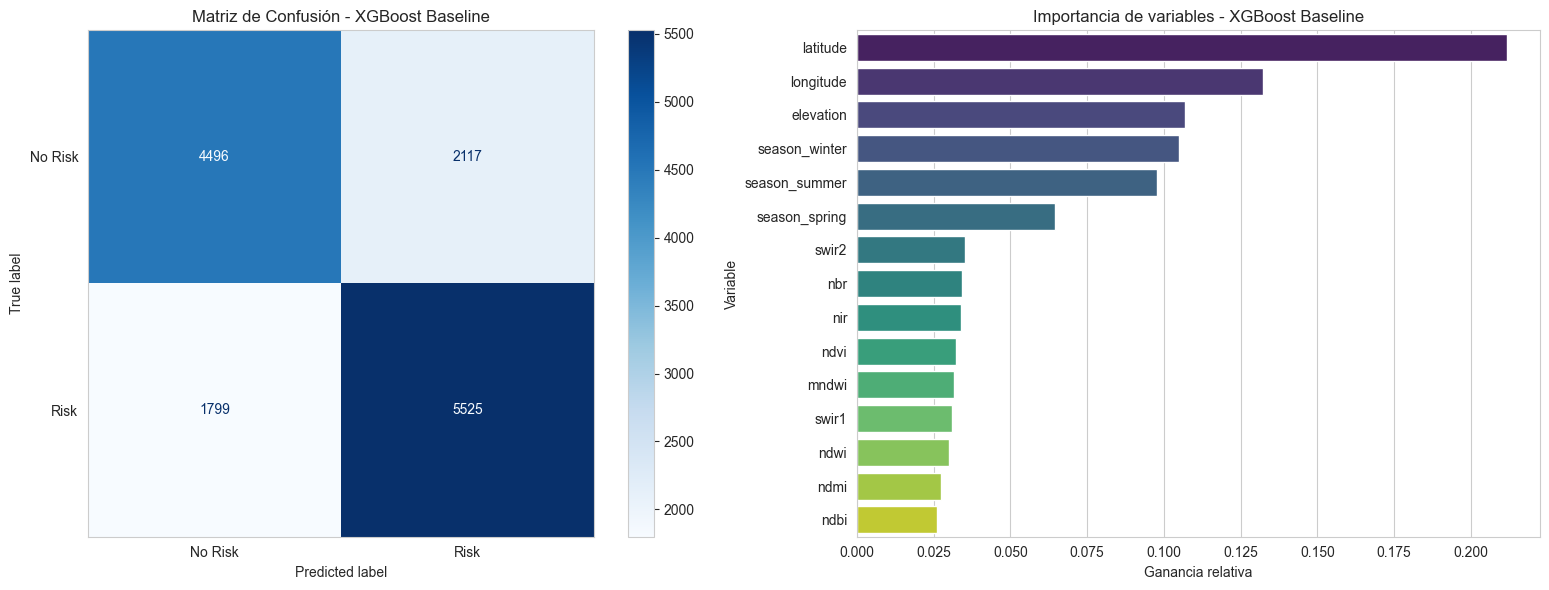

In [8]:
# ============================================================
# MATRIZ DE CONFUSIÓN E IMPORTANCIA DE VARIABLES
# ============================================================

# Visualizamos el rendimiento del modelo baseline mediante:
# - Matriz de confusión
# - Importancia de variables

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================

cm_base = confusion_matrix(y_test, y_pred_base)

disp_base = ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=['No Risk', 'Risk']
)

disp_base.plot(
    ax=ax[0],
    cmap='Blues',
    values_format='d'
)

ax[0].grid(False)

ax[0].set_title('Matriz de Confusión - XGBoost Baseline')

# ============================================================
# IMPORTANCIA DE VARIABLES
# ============================================================

importances_base = xgb_baseline.feature_importances_

indices_base = np.argsort(importances_base)[::-1]

sns.barplot(
    x=importances_base[indices_base],
    y=np.array(UPDATED_FEATURES)[indices_base],
    palette='viridis',
    ax=ax[1]
)

ax[1].set_title('Importancia de variables - XGBoost Baseline')
ax[1].set_xlabel('Ganancia relativa')
ax[1].set_ylabel('Variable')

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

## **Observación**

El modelo baseline de XGBoost muestra un rendimiento inicial sólido, pero la importancia de variables indica una alta dependencia de las coordenadas geográficas (`latitude` y `longitude`).

Esto sugiere que el modelo está utilizando fuertemente la localización espacial para clasificar el riesgo UHI. Aunque esta información puede mejorar el rendimiento predictivo dentro de Barcelona, también puede hacer que el modelo aprenda patrones asociados al mapa más que relaciones ambientales generalizables.

Por este motivo, antes de optimizar el modelo final, **se considera relevante entrenar una segunda versión eliminando las coordenadas geográficas**. Esta comparación permitirá evaluar si el modelo mantiene un buen rendimiento utilizando principalmente variables ambientales, espectrales y topográficas.

</div>

In [9]:
# ============================================================
# MODELO XGBOOST SIN COORDENADAS
# ============================================================

# Creamos una versión del dataset sin latitude ni longitude
# para reducir dependencia espacial del modelo.

features_no_geo = [
    'elevation','mndwi','nbr','ndbi',
    'ndmi','ndvi','ndwi','nir','swir1',
    'swir2','season'
]

X_no_geo = df_bcn[features_no_geo]
y = df_bcn['uhi_risk']

In [10]:
# ============================================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS SIN COORDENADAS
# ============================================================

# Aplicamos One-Hot Encoding sobre la variable 'season',
# manteniendo el mismo criterio utilizado en el modelo con coordenadas.

X_no_geo = pd.get_dummies(
    X_no_geo,
    columns=['season'],
    drop_first=True
)

# Actualizamos la lista de variables tras la codificación.
updated_features_no_geo = X_no_geo.columns.tolist()

# Verificamos las columnas generadas.
print(updated_features_no_geo)

['elevation', 'mndwi', 'nbr', 'ndbi', 'ndmi', 'ndvi', 'ndwi', 'nir', 'swir1', 'swir2', 'season_spring', 'season_summer', 'season_winter']


In [11]:
# ============================================================
# TRAIN / TEST SPLIT SIN COORDENADAS
# ============================================================

X_train_ng, X_test_ng, y_train_ng, y_test_ng = train_test_split(
    X_no_geo,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Dimensiones entrenamiento: {X_train_ng.shape[0]:,}")
print(f"Dimensiones prueba: {X_test_ng.shape[0]:,}")

Dimensiones entrenamiento: 55,746
Dimensiones prueba: 13,937


In [12]:
# ============================================================
# ENTRENAMIENTO XGBOOST SIN COORDENADAS
# ============================================================

# Entrenamos el modelo XGBoost sin coordenadas geográficas.

xgb_no_geo = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=2,
    reg_alpha=1,
    gamma=0,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_no_geo.fit(X_train_ng, y_train_ng)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [13]:
# ============================================================
# EVALUACIÓN XGBOOST SIN COORDENADAS
# ============================================================

y_pred_ng = xgb_no_geo.predict(X_test_ng)
y_probs_ng = xgb_no_geo.predict_proba(X_test_ng)[:, 1]

print("="*55)
print("CLASSIFICATION REPORT - XGBOOST SIN COORDENADAS")
print("="*55)

print(
    classification_report(
        y_test_ng,
        y_pred_ng,
        target_names=['No Risk', 'Risk']
    )
)

print(f"AUC-ROC: {roc_auc_score(y_test_ng, y_probs_ng):.4f}")

CLASSIFICATION REPORT - XGBOOST SIN COORDENADAS
              precision    recall  f1-score   support

     No Risk       0.67      0.62      0.64      6613
        Risk       0.68      0.72      0.70      7324

    accuracy                           0.68     13937
   macro avg       0.67      0.67      0.67     13937
weighted avg       0.67      0.68      0.67     13937

AUC-ROC: 0.7362


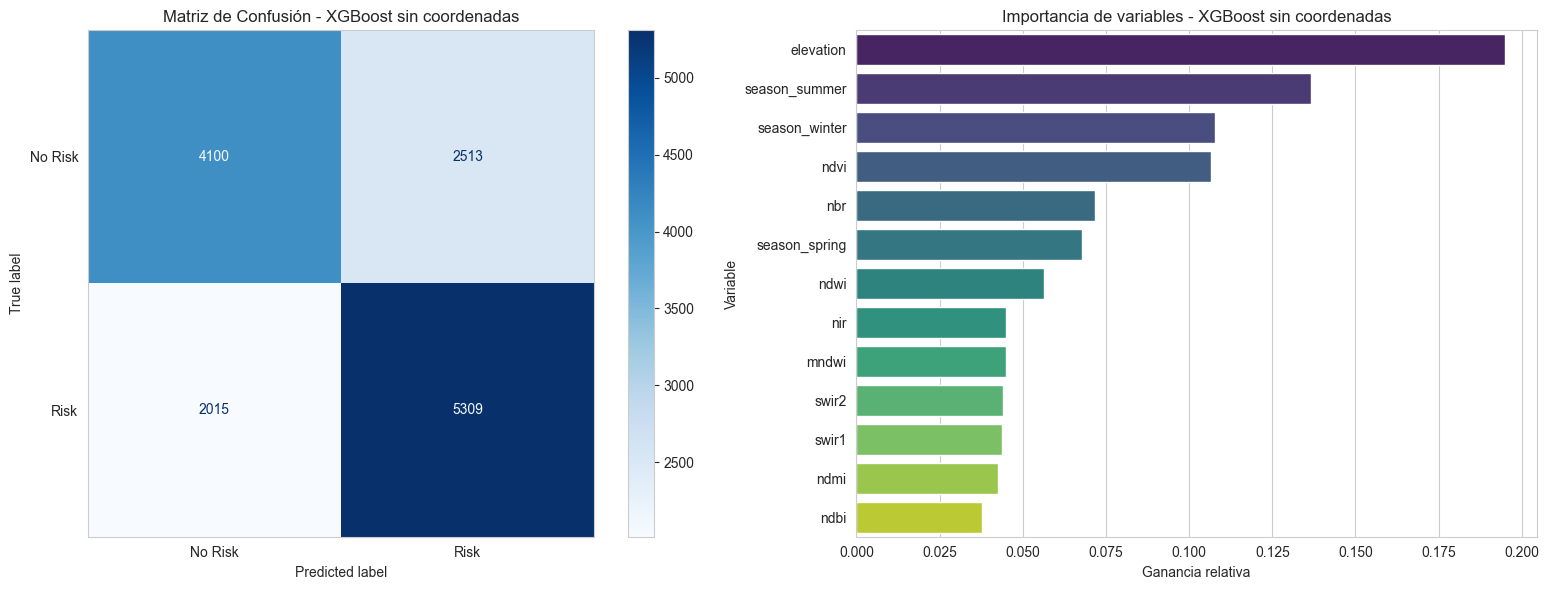

In [14]:
# ========================================================================
# MATRIZ DE CONFUSIÓN E IMPORTANCIA DE VARIABLES XGBOOST SIN COORDENADAS
# ========================================================================

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================

cm_ng = confusion_matrix(y_test_ng, y_pred_ng)

disp_ng = ConfusionMatrixDisplay(
    confusion_matrix=cm_ng,
    display_labels=['No Risk', 'Risk']
)

disp_ng.plot(
    ax=ax[0],
    cmap='Blues',
    values_format='d'
)

ax[0].grid(False)

ax[0].set_title('Matriz de Confusión - XGBoost sin coordenadas')

# ============================================================
# IMPORTANCIA DE VARIABLES
# ============================================================

importances_ng = xgb_no_geo.feature_importances_

indices_ng = np.argsort(importances_ng)[::-1]

sns.barplot(
    x=importances_ng[indices_ng],
    y=np.array(updated_features_no_geo)[indices_ng],
    palette='viridis',
    ax=ax[1]
)

ax[1].set_title('Importancia de variables - XGBoost sin coordenadas')
ax[1].set_xlabel('Ganancia relativa')
ax[1].set_ylabel('Variable')

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

## **Observación comparación modelos XGBoost**

Se entrenaron dos versiones del modelo XGBoost:

- Un modelo utilizando coordenadas geográficas (`latitude` y `longitude`).
- Un modelo eliminando las coordenadas para evaluar el impacto de la dependencia espacial en el aprendizaje del modelo.

| Modelo | Accuracy | Recall (Risk) | F1-score (Risk) | AUC-ROC |
|---|---|---|---|---|
| Con coordenadas | 0.72 | 0.75 | 0.74 | 0.8007 |
| Sin coordenadas | 0.68 | 0.73 | 0.70 | 0.7367 |

La eliminación de las coordenadas produce una disminución moderada del rendimiento, aunque el modelo no se derrumba. Esto resulta relevante, ya que sugiere que XGBoost no está simplemente memorizando ubicaciones geográficas específicas.

Si la caída hubiese sido extrema, podría interpretarse como una fuerte dependencia espacial o sobreajuste a la localización. Sin embargo, la reducción observada es relativamente contenida, indicando que las coordenadas ayudan al modelo, pero no representan la única fuente de información relevante.

Incluso sin `latitude` y `longitude`, el modelo mantiene capacidad para detectar patrones asociados al fenómeno Urban Heat Island mediante variables ambientales y espectrales relacionadas con vegetación, humedad, urbanización y temperatura superficial.

Además, el recall de la clase `Risk` continúa siendo relativamente alto (`0.73`), lo que indica que el modelo sigue identificando correctamente una gran parte de las zonas de riesgo térmico aun sin información espacial explícita.

En conjunto, esta comparación aporta mayor robustez al análisis, ya que demuestra que el modelo mejora al incorporar información geográfica, pero continúa aprendiendo patrones ambientales reales incluso cuando las coordenadas son eliminadas.

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

## **Decisión final del modelo a optimizar**

Aunque el modelo XGBoost que incorpora coordenadas geográficas (`latitude` y `longitude`) obtiene mejores métricas globales, se decidió continuar el proceso de optimización utilizando la versión **sin coordenadas geográficas**.

Esta decisión busca reducir la dependencia espacial del modelo y favorecer un aprendizaje basado principalmente en variables ambientales y térmicas relacionadas con el fenómeno Urban Heat Island (UHI).

El objetivo no es que el modelo aprenda únicamente a reconocer zonas específicas del mapa, sino que sea capaz de identificar patrones físicos asociados al riesgo térmico urbano, tales como:

- Temperatura superficial.
- Cobertura vegetal.
- Humedad.
- Urbanización.
- Diferencias térmicas.
- Elevación y estacionalidad.

La comparación entre ambos modelos mostró que, al eliminar las coordenadas, el rendimiento disminuye de forma moderada, pero el modelo no se derrumba. Esto indica que las variables ambientales continúan aportando información predictiva relevante incluso sin información espacial explícita.

Además, el modelo sin coordenadas mantiene métricas razonablemente sólidas para la clase `Risk`, especialmente en términos de recall y F1-score, lo que demuestra que sigue siendo capaz de identificar zonas de riesgo térmico urbano de forma consistente.

En consecuencia, se considera que **el modelo sin coordenadas ofrece una aproximación más robusta, interpretable y generalizable desde el punto de vista ambiental**, manteniendo además un rendimiento competitivo para la detección de zonas de riesgo UHI.

</div>

In [15]:
# ============================================================
# OPTIMIZACIÓN XGBOOST SIN COORDENADAS
# ============================================================

# Definimos una rejilla de hiperparámetros para buscar
# una mejor combinación para el modelo sin coordenadas.

param_dist_ng = {
    'n_estimators': [400, 600, 800, 1000],
    'learning_rate': [0.02, 0.03, 0.05, 0.08],
    'max_depth': [5, 6, 7, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.1, 1, 5],
    'reg_lambda': [1, 2, 5, 10]
}

cv_strategy_ng = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

In [16]:
# ============================================================
# BÚSQUEDA ALEATORIA DE HIPERPARÁMETROS
# ============================================================

# Ejecutamos RandomizedSearchCV sobre el dataset sin coordenadas.
# Usamos AUC-ROC para mantener la lógica original del modelo XGBoost.

xgb_search_ng = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ),
    param_distributions=param_dist_ng,
    n_iter=15,
    scoring='roc_auc',
    cv=cv_strategy_ng,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search_ng.fit(X_train_ng, y_train_ng)

best_xgb_ng = xgb_search_ng.best_estimator_

Fitting 4 folds for each of 15 candidates, totalling 60 fits


In [17]:
# ============================================================
# MEJORES HIPERPARÁMETROS ENCONTRADOS
# ============================================================

# Mostramos la mejor combinación encontrada.

print("Mejores hiperparámetros encontrados:")

for param, value in xgb_search_ng.best_params_.items():
    print(f"- {param}: {value}")

print(f"\nMejor AUC-ROC en validación cruzada: {xgb_search_ng.best_score_:.4f}")

Mejores hiperparámetros encontrados:
- subsample: 0.9
- reg_lambda: 1
- reg_alpha: 1
- n_estimators: 600
- max_depth: 7
- learning_rate: 0.02
- gamma: 0.5
- colsample_bytree: 0.8

Mejor AUC-ROC en validación cruzada: 0.7430


In [18]:
# ============================================================
# EVALUACIÓN XGBOOST OPTIMIZADO SIN COORDENADAS
# ============================================================

# Evaluamos el mejor modelo encontrado sobre el conjunto de prueba.

y_pred_ng_opt = best_xgb_ng.predict(X_test_ng)
y_probs_ng_opt = best_xgb_ng.predict_proba(X_test_ng)[:, 1]

print("=" * 65)
print("CLASSIFICATION REPORT - XGBOOST OPTIMIZADO SIN COORDENADAS")
print("=" * 65)

print(
    classification_report(
        y_test_ng,
        y_pred_ng_opt,
        target_names=['No Risk', 'Risk']
    )
)

print(f"AUC-ROC: {roc_auc_score(y_test_ng, y_probs_ng_opt):.4f}")

CLASSIFICATION REPORT - XGBOOST OPTIMIZADO SIN COORDENADAS
              precision    recall  f1-score   support

     No Risk       0.68      0.63      0.65      6613
        Risk       0.68      0.73      0.71      7324

    accuracy                           0.68     13937
   macro avg       0.68      0.68      0.68     13937
weighted avg       0.68      0.68      0.68     13937

AUC-ROC: 0.7459


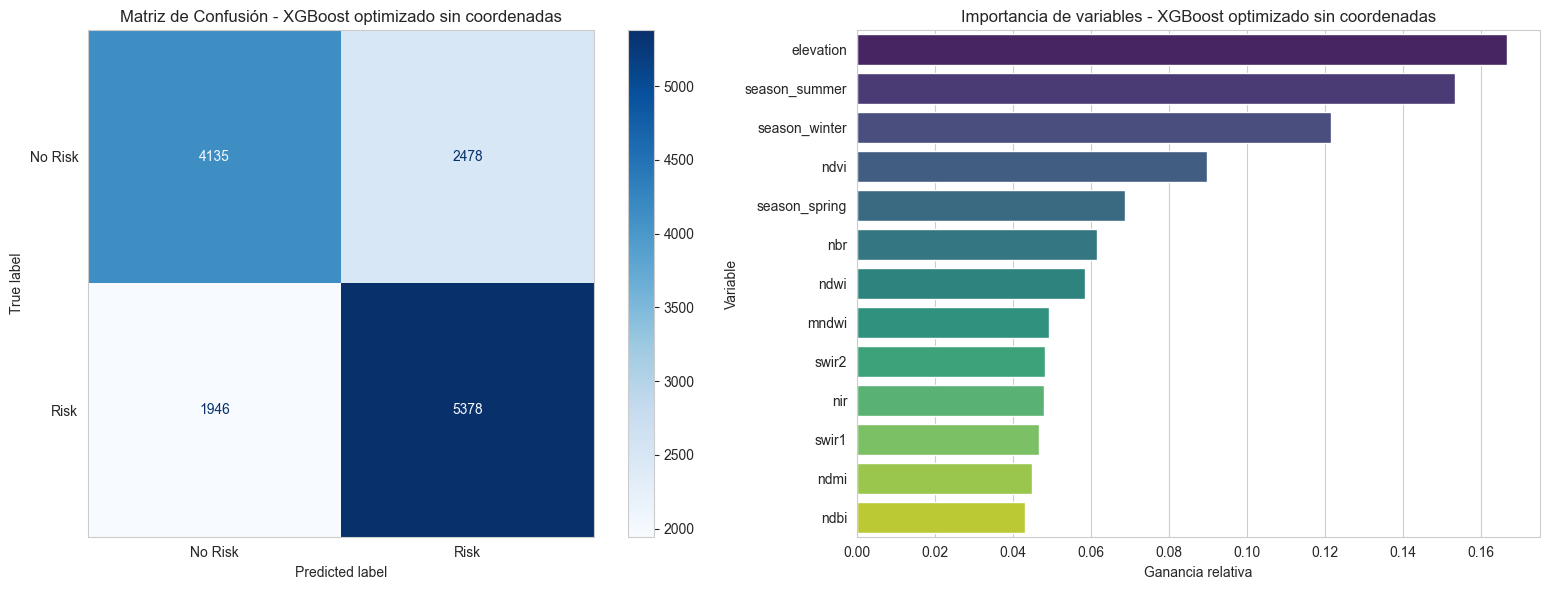

In [19]:
# ============================================================
# MATRIZ DE CONFUSIÓN E IMPORTANCIA DE VARIABLES
# XGBOOST OPTIMIZADO SIN COORDENADAS
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Matriz de confusión

cm_ng_opt = confusion_matrix(y_test_ng, y_pred_ng_opt)

disp_ng_opt = ConfusionMatrixDisplay(
    confusion_matrix=cm_ng_opt,
    display_labels=['No Risk', 'Risk']
)

disp_ng_opt.plot(
    ax=ax[0],
    cmap='Blues',
    values_format='d'
)

ax[0].grid(False)
ax[0].set_title('Matriz de Confusión - XGBoost optimizado sin coordenadas')

# Importancia de variables

importances_ng_opt = best_xgb_ng.feature_importances_

feature_names_ng_opt = X_train_ng.columns.tolist()

indices_ng_opt = np.argsort(importances_ng_opt)[::-1]

sns.barplot(
    x=importances_ng_opt[indices_ng_opt],
    y=np.array(feature_names_ng_opt)[indices_ng_opt],
    palette='viridis',
    ax=ax[1]
)

ax[1].set_title('Importancia de variables - XGBoost optimizado sin coordenadas')
ax[1].set_xlabel('Ganancia relativa')
ax[1].set_ylabel('Variable')

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

# Observación optimización XGBoost sin coordenadas

Se compararon dos versiones del modelo XGBoost sin coordenadas geográficas:

- Un modelo baseline utilizando únicamente variables ambientales y espectrales.
- Un modelo optimizado mediante RandomizedSearchCV para ajustar hiperparámetros.

| Modelo | Accuracy | Recall (Risk) | F1-score (Risk) | AUC-ROC |
|---|---|---|---|---|
| Baseline sin coordenadas | 0.68 | 0.73 | 0.70 | 0.7367 |
| Optimizado sin coordenadas | 0.68 | 0.73 | 0.71 | 0.7454 |

La optimización de hiperparámetros produce una mejora ligera en el AUC-ROC y en el F1-score de la clase `Risk`, mientras que el accuracy global permanece estable.

Aunque la diferencia entre ambos modelos no es extrema, el modelo optimizado muestra un comportamiento ligeramente más robusto y consistente en la detección de zonas de riesgo térmico urbano.

Además, la importancia de variables continúa evidenciando que índices ambientales y espectrales como `NDVI`, `NBR`, `MNDWI` y la `elevation` aportan información relevante para detectar el fenómeno Urban Heat Island (UHI), incluso sin utilizar coordenadas geográficas explícitas.

Desde el punto de vista del proyecto, este resultado es especialmente relevante, ya que demuestra que el modelo no depende únicamente de la localización espacial para realizar sus predicciones, sino que aprende patrones ambientales reales asociados al riesgo térmico urbano.

Por este motivo, se decide conservar como modelo final el **XGBoost optimizado sin coordenadas**, ya que ofrece una mejor combinación entre:

- Robustez.
- Interpretabilidad ambiental.
- Generalización.
- Rendimiento predictivo razonable sin dependencia espacial directa.

En consecuencia, este será el modelo utilizado posteriormente para el despliegue de la aplicación interactiva mediante Streamlit.

</div>

In [20]:
# ============================================================
# GUARDADO DEL MODELO FINAL
# ============================================================

# Guardamos el modelo final optimizado sin coordenadas
# para utilizarlo posteriormente en la aplicación Streamlit.

import joblib

joblib.dump(
    best_xgb_ng,
    '../models/xgboost_uhi_no_geo_optimized.sav'
)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.
